Columns in dataset:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='str')


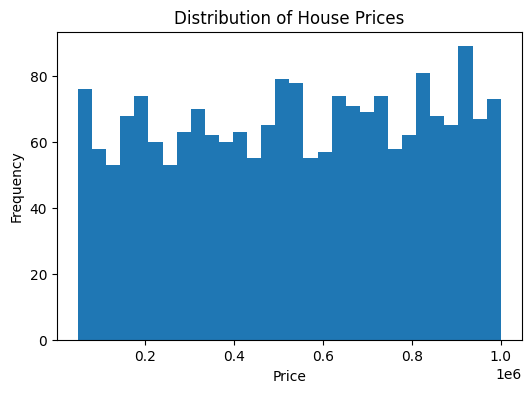

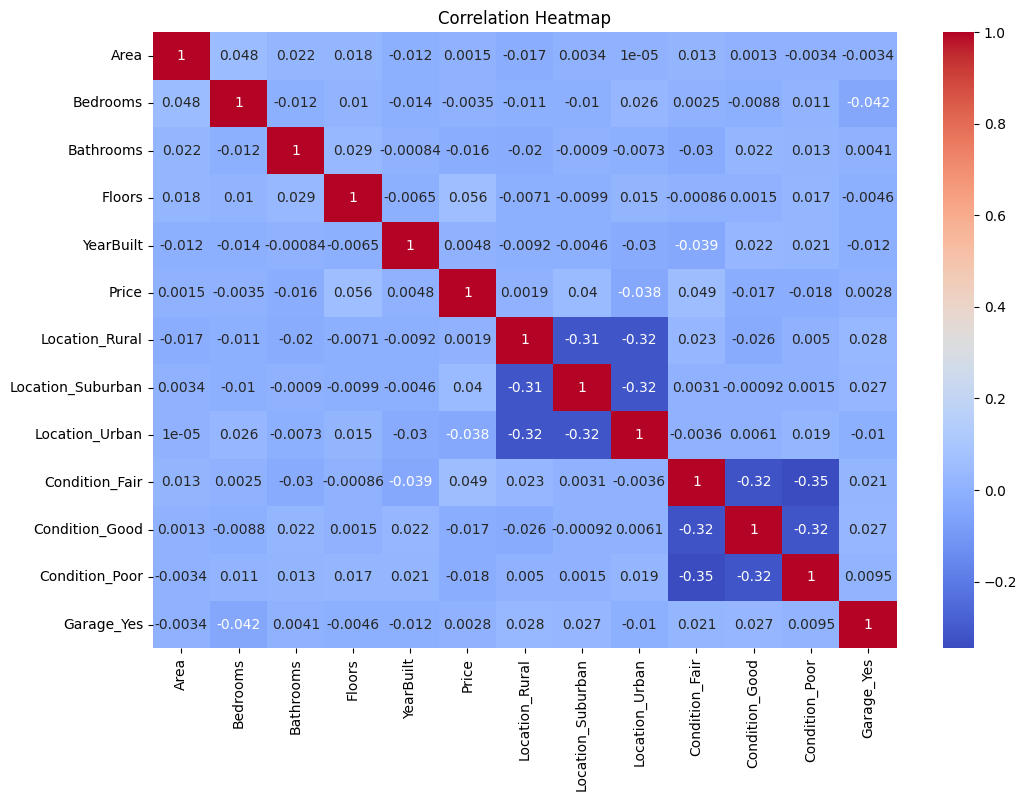


Model Performance Comparison:
---------------------------------
Linear Regression -> R2: -0.0067, MSE: 78321466146.03
Decision Tree     -> R2: -1.0705, MSE: 161085335369.78
Random Forest     -> R2: -0.0964, MSE: 85298979559.81


In [2]:
# =====================================
# 1. Import Required Libraries
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# =====================================
# 2. Load Dataset
# =====================================

df = pd.read_csv("House Price Prediction Dataset.csv")

print("Columns in dataset:")
print(df.columns)


# =====================================
# 3. Drop Unnecessary Column
# =====================================

df = df.drop("Id", axis=1)


# =====================================
# 4. Data Visualization (Histogram)
# =====================================

plt.figure(figsize=(6,4))
plt.hist(df["Price"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# =====================================
# 5. Convert Categorical Columns
# =====================================

df = pd.get_dummies(df, drop_first=True)


# =====================================
# 6. Correlation Heatmap
# =====================================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# =====================================
# 7. Define Features and Target
# =====================================

X = df.drop("Price", axis=1)
y = df["Price"]


# =====================================
# 8. Train-Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =====================================
# 9. Feature Scaling (for Linear Regression)
# =====================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =====================================
# 10. Linear Regression
# =====================================

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_r2 = r2_score(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)


# =====================================
# 11. Decision Tree
# =====================================

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_r2 = r2_score(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)


# =====================================
# 12. Random Forest
# =====================================

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)


# =====================================
# 13. Model Comparison
# =====================================

print("\nModel Performance Comparison:")
print("---------------------------------")
print(f"Linear Regression -> R2: {lr_r2:.4f}, MSE: {lr_mse:.2f}")
print(f"Decision Tree     -> R2: {dt_r2:.4f}, MSE: {dt_mse:.2f}")
print(f"Random Forest     -> R2: {rf_r2:.4f}, MSE: {rf_mse:.2f}")